# Setup
---

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
import ast

import importlib
import tools.pltw as pltw

def reload_modules():
    importlib.reload(pltw)


In [7]:
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# Datasets
---

In [9]:
hclns_reassignments_df = pd.read_csv(
    "/home/pbiel/repos/mrp/analysis/hclns_reassignments.csv",
    converters={
        'ProcessResourceRequirements': ast.literal_eval,
    }
)
hclns_reassignments_df['ProcessSize'] = hclns_reassignments_df['ProcessResourceRequirements'].apply(sum)

print(f"Solution contains {len(hclns_reassignments_df)} reassignments.")
hclns_reassignments_df.head()


Solution contains 330 reassignments.


,MoveNum,ProcessID,SourceMachine,DestMachine,OriginalMachine,Service,MoveCost,ProcessResourceRequirements,Improvement,Timestamp,...,SourceMachineCapacities,DestMachineCapacities,SourceMachineTransientUsage,DestMachineTransientUsage,SourceMachineProcessCount,DestMachineProcessCount,LoadCost,BalanceCost,SolutionCost,ProcessSize
0,1,138,53,76,53,141,1,"[621123, 391575, 25988, 3787006]",2.4285,1755094251450,...,"[3135647,3285240,1668729,10776271]","[2674055,2045617,3245821,7644847]","[0,0,0,10764554]","[0,0,0,4919106]",16,12,1035867720,0,1035867931,4825692
1,2,780,47,60,47,769,1,"[386106, 346913, 22844, 1338795]",3.8310,1755094251453,...,"[2821005,3137099,3083520,6584977]","[2513744,2131731,3885345,5158196]","[0,0,0,6584603]","[0,0,0,4519084]",14,16,1020977790,0,1020978102,2094658
2,3,807,38,31,38,795,1,"[631212, 347412, 6813, 769078]",5.4422,1755094251457,...,"[2328824,1520928,458113,5324291]","[1039346,1300298,1034346,1191742]","[0,0,0,5324291]","[0,0,0,836719]",9,4,1003872190,0,1003872703,1754515
3,4,54,75,46,75,61,1,"[745972, 749817, 639473, 401458]",6.9562,1755094251459,...,"[4459900,3475529,1698242,18159103]","[1540978,1177326,3555778,1463613]","[0,0,0,18159103]","[0,0,0,1014700]",14,9,987798210,0,987798824,2536720
4,5,129,57,71,57,132,1,"[379872, 295579, 1493, 1126371]",7.1665,1755094251459,...,"[2132781,2745036,807524,8354675]","[3415134,5358117,1717340,10941650]","[0,0,0,8354675]","[0,0,0,10828804]",12,14,985565180,0,985565995,1803315


In [10]:
vns_reassignments_df = pd.read_csv(
    "/home/pbiel/repos/mrp/analysis/vns_reassignments.csv",
    converters={
        'ProcessResourceRequirements': ast.literal_eval,
    }
)
vns_reassignments_df['ProcessSize'] = vns_reassignments_df['ProcessResourceRequirements'].apply(sum)

print(f"Solution contains {len(vns_reassignments_df)} reassignments.")
vns_reassignments_df.head()


Solution contains 4344 reassignments.


,MoveNum,ProcessID,SourceMachine,DestMachine,OriginalMachine,Service,MoveCost,ProcessResourceRequirements,Improvement,Timestamp,...,SourceMachineCapacities,DestMachineCapacities,SourceMachineTransientUsage,DestMachineTransientUsage,SourceMachineProcessCount,DestMachineProcessCount,LoadCost,BalanceCost,SolutionCost,ProcessSize
0,1,1,8,14,48,8,1,"[35574, 21914, 48459]",0.0,1756641868000,...,"[2344071,3031239,3573218]","[3233735,3655313,8642089]","[1759408,2076047,3059201]","[2737196,2642254,8566626]",12,34,395942500,2426474200,2823506710,105947
1,2,2,0,11,34,17,1,"[6429, 4024, 17106]",0.0,1756641868000,...,"[722040,645675,789895]","[2972420,2877021,6716092]","[624553,488000,754104]","[2871011,2688144,6723251]",11,19,396330900,2426474200,2823895110,27559
2,3,6,16,47,16,2,1,"[171832, 137485, 49123]",0.0,1756641868000,...,"[4087795,4462350,9561546]","[6578597,7775116,14119786]","[3261202,3022402,8608708]","[5779889,7051162,14027127]",16,29,413013500,2426474200,2840579720,358440
3,4,9,47,32,47,81,1,"[3738, 1896, 2877]",0.0,1756641868000,...,"[6578597,7775116,14119786]","[4944858,5498738,7857445]","[5776151,7049266,14027127]","[4373714,4377855,7858431]",28,21,412829300,2426474200,2840397530,8511
4,5,11,26,20,14,4,1,"[421150, 835413, 82703]",0.0,1756641868000,...,"[2940295,3772766,10030869]","[4566377,6030697,13558852]","[1650034,1957009,9936272]","[3815227,5757139,13530853]",9,13,524503900,2426474200,2952072130,1339266


In [65]:
cplns_reassignments_df = pd.read_csv(
    "/home/pbiel/repos/mrp/analysis/cplns_reassignments.csv",
)
lookup = (
    hclns_reassignments_df[['ProcessID', 'ProcessSize']]
    .drop_duplicates('ProcessID')
    .set_index('ProcessID')['ProcessSize']
)
cplns_reassignments_df = cplns_reassignments_df.copy()
cplns_reassignments_df['ProcessSize'] = cplns_reassignments_df['processId'].map(lookup)
cplns_reassignments_df['ProcessSize'] = cplns_reassignments_df['ProcessSize'].fillna(0).astype(int)

lookup = (
    vns_reassignments_df[['ProcessID', 'ProcessSize']]
    .drop_duplicates('ProcessID')
    .set_index('ProcessID')['ProcessSize']
)
cplns_reassignments_df = cplns_reassignments_df.copy()
cplns_reassignments_df['ProcessSize'] = cplns_reassignments_df['processId'].map(lookup)
cplns_reassignments_df['ProcessSize'] = cplns_reassignments_df['ProcessSize'].fillna(0).astype(int)

cplns_reassignments_df = cplns_reassignments_df.rename(columns={
    "moveNumber": "MoveNum", 
    "processId": "ProcessID",
    "solutionId": "SolutionId",
    "solutionCost": "SolutionCost",
    "sourceMachine": "SourceMachine",
    "destMachine": "DestMachine",
    })

print(f"Solution contains {len(cplns_reassignments_df)} reassignments.")
cplns_reassignments_df.head()


Solution contains 25440 reassignments.


,MoveNum,ProcessID,SourceMachine,DestMachine,moveCost,improvement,timestamp,SolutionId,SolutionCost,ProcessSize
0,1,973,20,47,0,0,0.0,1,601689777,128112
1,2,378,20,47,0,0,0.0,1,601689777,214233
2,3,756,20,12,0,0,0.0,1,601689777,1115028
3,4,844,20,33,0,0,0.0,1,601689777,0
4,5,638,20,38,0,0,0.0,1,601689777,1323574


# Utitilies and Tools
---

In [72]:
def run_analysis_for_reassignments_dataset(df):
    print(f"---------------------------------------------------")
    print("Summary of High-Level Dataset Overview")
    print(f"---------------------------------------------------")
    
    print(f"Total reassignments: {len(df)}")
    print(f"Unique processes moved: {df['ProcessID'].nunique()}")
    print(f"Unique source machines: {df['SourceMachine'].nunique()}")
    print(f"Unique destination machines: {df['DestMachine'].nunique()}")
    print(f"Unique solutions: {df['SolutionId'].nunique()}")
    print(f"Initial solution cost: {df['SolutionCost'].iloc[0]}")
    print(f"Final solution cost: {df['SolutionCost'].iloc[-1]}")
    print(f"Cost improvement: {df['SolutionCost'].iloc[0] - df['SolutionCost'].iloc[-1]}")
    
    # Additional metrics
    print(f"Average process size: {df['ProcessSize'].mean():.2f}")

    # Big process reassignments (threshold: process size > 2e6)
    big_process_threshold = 2e6
    big_process_reassignments = df[df['ProcessSize'] > big_process_threshold]
    print(f"Big process reassignments (size > {big_process_threshold:.0e}): {len(big_process_reassignments)}")
    
    # Reassignments per solution
    reassignments_per_solution = df.groupby('SolutionId').size()
    print(f"Reassignments per solution: {reassignments_per_solution.tolist()}")
    print(f"Average reassignments per solution: {reassignments_per_solution.mean():.2f}")
    
    print(f"---------------------------------------------------")
    print("Analysis of Process Movements")
    print("---------------------------------------------------")
    
    process_moves = df['ProcessID'].value_counts()

    print(f"Most frequently moved processes:")
    print(process_moves.head(10))
    print(f"\nMovement distribution:")
    print(f"Processes moved once: {sum(process_moves == 1)}")
    print(f"Processes moved 2-5 times: {sum((process_moves >= 2) & (process_moves <= 5))}")
    print(f"Processes moved >5 times: {sum(process_moves > 5)}")
    print(f"Max moves for single process: {process_moves.max()}")


In [15]:
def calculate_points_of_neighbourhood_changes(df):
    """
    Function to calculate state changes in the neighbourhoods based on SolutionId.
    Procedure calculates a boolean mask based on solution ID changes, retrieves indices where it changes, and lastly includes the end of the DataFrame.
    """
    state_changes_mask = df['SolutionId'].ne(df['SolutionId'].shift())
    state_changes_idx = state_changes_mask.index[state_changes_mask].tolist()
    state_changes_idx = state_changes_idx + [len(df)]
    
    return state_changes_idx


# Analysis
---

In [73]:
run_analysis_for_reassignments_dataset(hclns_reassignments_df)


---------------------------------------------------
Summary of High-Level Dataset Overview
---------------------------------------------------
Total reassignments: 330
Unique processes moved: 203
Unique source machines: 85
Unique destination machines: 71
Unique solutions: 330
Initial solution cost: 1035867931
Final solution cost: 777545063
Cost improvement: 258322868
Average process size: 268519.64
Big process reassignments (size > 2e+06): 4
Reassignments per solution: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 

In [74]:
run_analysis_for_reassignments_dataset(vns_reassignments_df)


---------------------------------------------------
Summary of High-Level Dataset Overview
---------------------------------------------------
Total reassignments: 4344
Unique processes moved: 842
Unique source machines: 50
Unique destination machines: 50
Unique solutions: 8
Initial solution cost: 2823506710
Final solution cost: 2768705380
Cost improvement: 54801330
Average process size: 212063.09
Big process reassignments (size > 2e+06): 45
Reassignments per solution: [524, 537, 470, 525, 648, 467, 489, 684]
Average reassignments per solution: 543.00
---------------------------------------------------
Analysis of Process Movements
---------------------------------------------------
Most frequently moved processes:
ProcessID
518    8
516    8
976    8
959    8
951    8
555    8
554    8
140    8
138    8
90     8
Name: count, dtype: int64

Movement distribution:
Processes moved once: 65
Processes moved 2-5 times: 331
Processes moved >5 times: 446
Max moves for single process: 8


In [77]:
run_analysis_for_reassignments_dataset(cplns_reassignments_df)


---------------------------------------------------
Summary of High-Level Dataset Overview
---------------------------------------------------
Total reassignments: 25440
Unique processes moved: 787
Unique source machines: 50
Unique destination machines: 50
Unique solutions: 6130
Initial solution cost: 601689777
Final solution cost: 249988764
Cost improvement: 351701013
Average process size: 36785.56
Big process reassignments (size > 2e+06): 9
Reassignments per solution: [7, 7, 5, 7, 2, 3, 9, 8, 2, 8, 7, 5, 5, 6, 1, 5, 4, 3, 8, 6, 1, 6, 7, 1, 1, 6, 9, 4, 4, 3, 3, 3, 4, 4, 1, 6, 4, 3, 7, 2, 4, 2, 3, 3, 6, 2, 1, 7, 5, 4, 3, 1, 7, 4, 2, 3, 3, 4, 6, 2, 3, 5, 3, 3, 1, 2, 2, 3, 3, 2, 2, 3, 1, 1, 3, 3, 3, 3, 4, 2, 2, 3, 2, 6, 4, 3, 2, 2, 3, 1, 2, 3, 1, 4, 1, 2, 4, 4, 1, 4, 5, 2, 1, 2, 5, 2, 3, 2, 3, 3, 1, 1, 2, 1, 3, 1, 1, 3, 3, 3, 1, 2, 5, 1, 1, 1, 2, 2, 2, 1, 1, 2, 2, 4, 1, 2, 3, 1, 3, 1, 2, 3, 3, 2, 1, 1, 1, 1, 1, 2, 3, 2, 1, 1, 3, 2, 1, 2, 1, 3, 5, 6, 2, 3, 3, 1, 1, 3, 2, 2, 3, 1, 1, 3, 2,

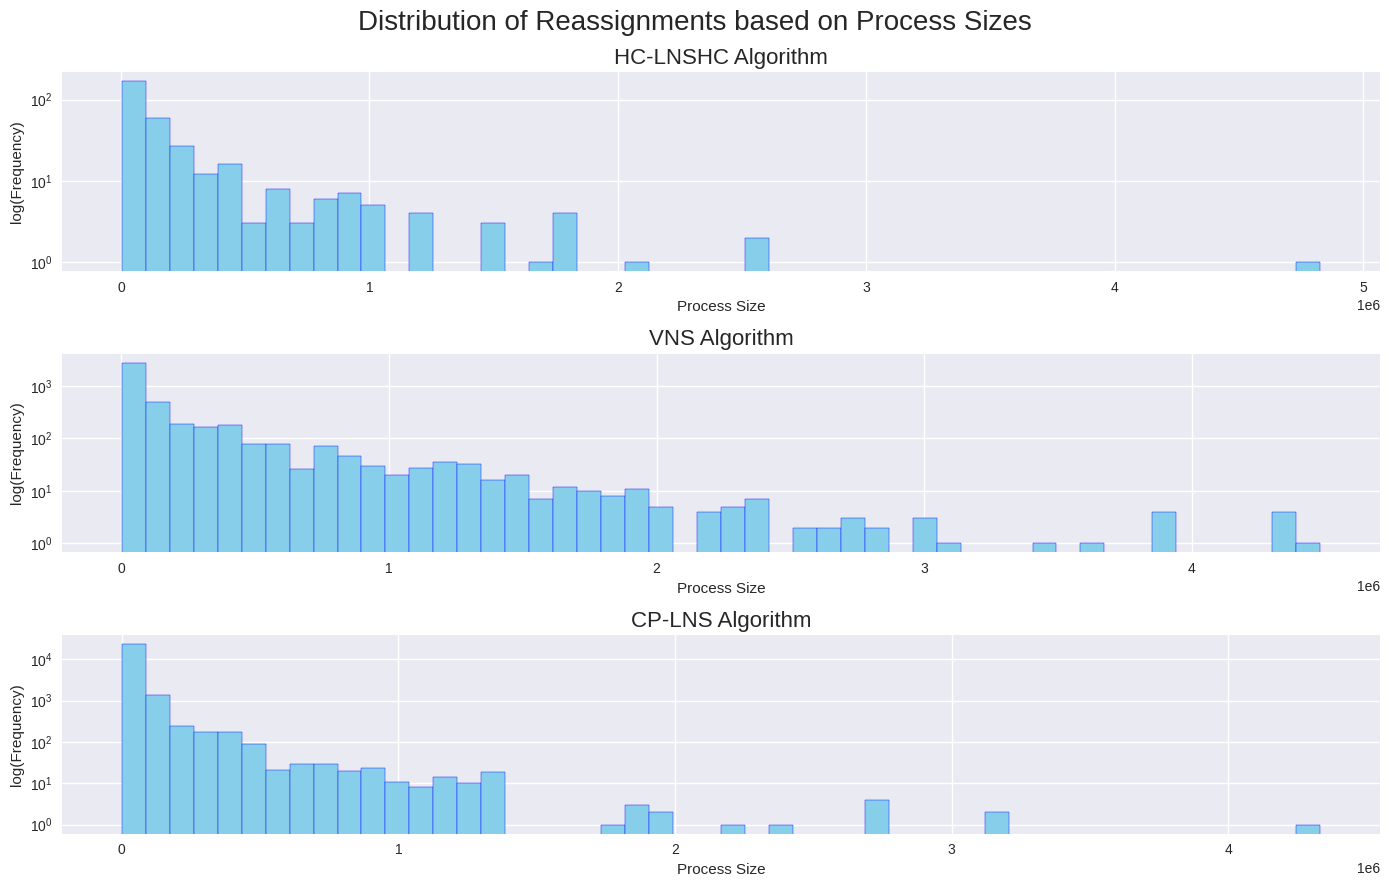

In [ ]:
n_plots = 3
h_plot  = 3

fig, axs = plt.subplots(n_plots, 1, figsize=(14, n_plots*h_plot))
fig.suptitle("Distribution of Reassignments based on Process Sizes", fontsize=20)

axs = axs.flatten()

idx = 0
axs[idx].hist(hclns_reassignments_df['ProcessSize'], bins=50, color='skyblue', edgecolor='blue')
axs[idx].set_title("HC-LNSHC Algorithm", fontsize=16)
axs[idx].set_xlabel('Process Size')

idx = 1
axs[idx].hist(vns_reassignments_df['ProcessSize'], bins=50, color='skyblue', edgecolor='blue')
axs[idx].set_title("VNS Algorithm", fontsize=16)
axs[idx].set_xlabel('Process Size')


idx = 2
axs[idx].hist(cplns_reassignments_df['ProcessSize'], bins=50, color='skyblue', edgecolor='blue')
axs[idx].set_title("CP-LNS Algorithm", fontsize=16)
axs[idx].set_xlabel('Process Size')

for ax in fig.get_axes():
    ax.set_yscale('log')
    ax.set_ylabel('log(Frequency)')
    ax.margins(0.05)
    ax.grid(zorder=0)

plt.tight_layout()


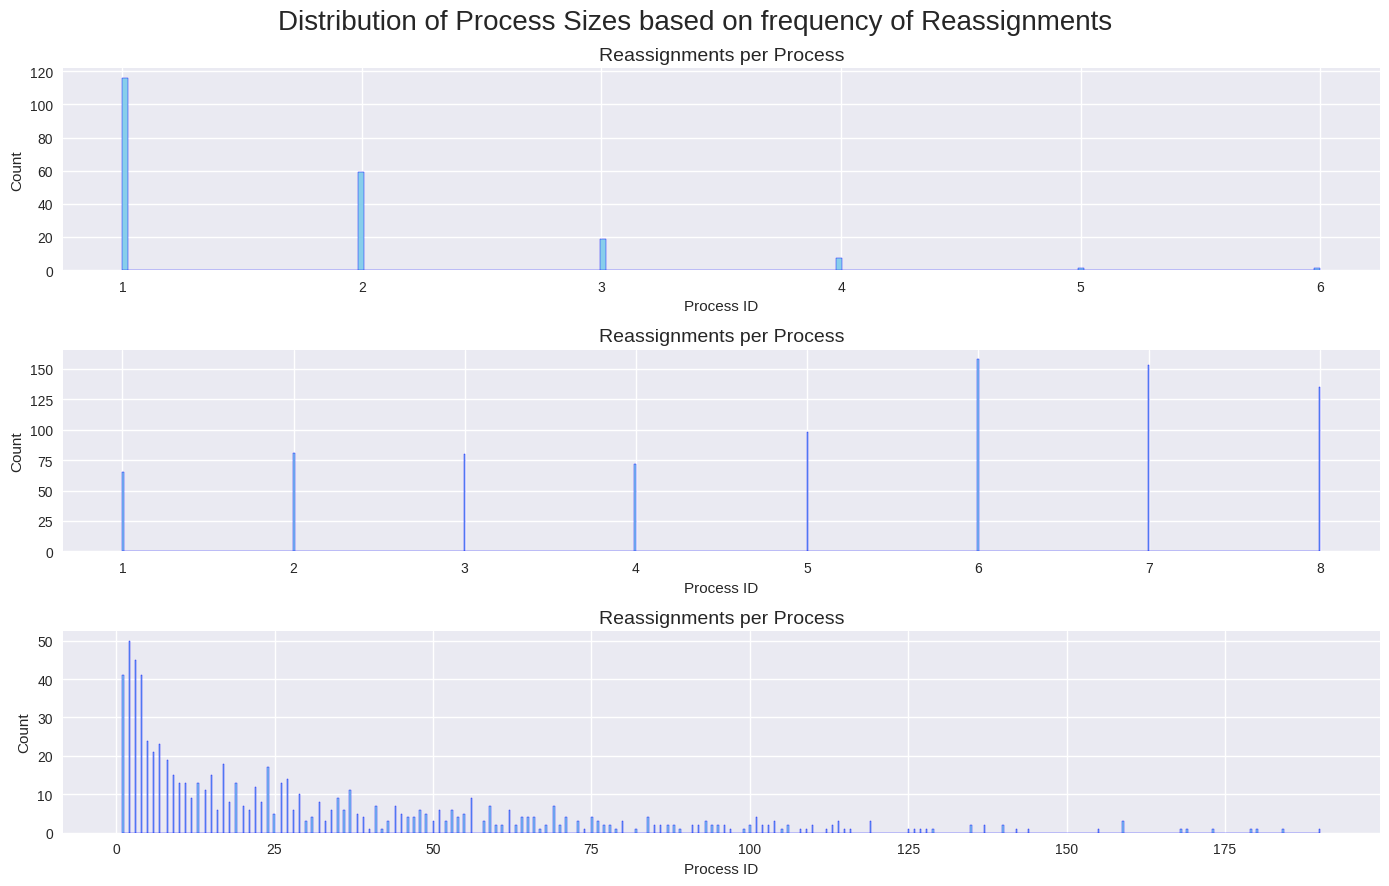

In [68]:
n_plots = 3
h_plot  = 3

fig, axs = plt.subplots(n_plots, 1, figsize=(14, n_plots*h_plot))
fig.suptitle("Distribution of Process Sizes based on frequency of Reassignments", fontsize=20)

axs = axs.flatten()

idx = 0
axs[idx].hist(hclns_reassignments_df['ProcessID'].value_counts(), bins=hclns_reassignments_df['ProcessID'].nunique(), color='skyblue', edgecolor='blue')
axs[idx].set_title("Reassignments per Process", fontsize=14)
axs[idx].set_ylabel('Count')
axs[idx].set_xlabel('Process ID')

idx = 1
axs[idx].hist(vns_reassignments_df['ProcessID'].value_counts(), bins=vns_reassignments_df['ProcessID'].nunique(), color='skyblue', edgecolor='blue')
axs[idx].set_title("Reassignments per Process", fontsize=14)
axs[idx].set_ylabel('Count')
axs[idx].set_xlabel('Process ID')

idx = 2
axs[idx].hist(cplns_reassignments_df['ProcessID'].value_counts(), bins=cplns_reassignments_df['ProcessID'].nunique(), color='skyblue', edgecolor='blue')
axs[idx].set_title("Reassignments per Process", fontsize=14)
axs[idx].set_ylabel('Count')
axs[idx].set_xlabel('Process ID')

for ax in fig.get_axes():
    ax.margins(0.05)
    ax.grid(zorder=0)

plt.tight_layout()


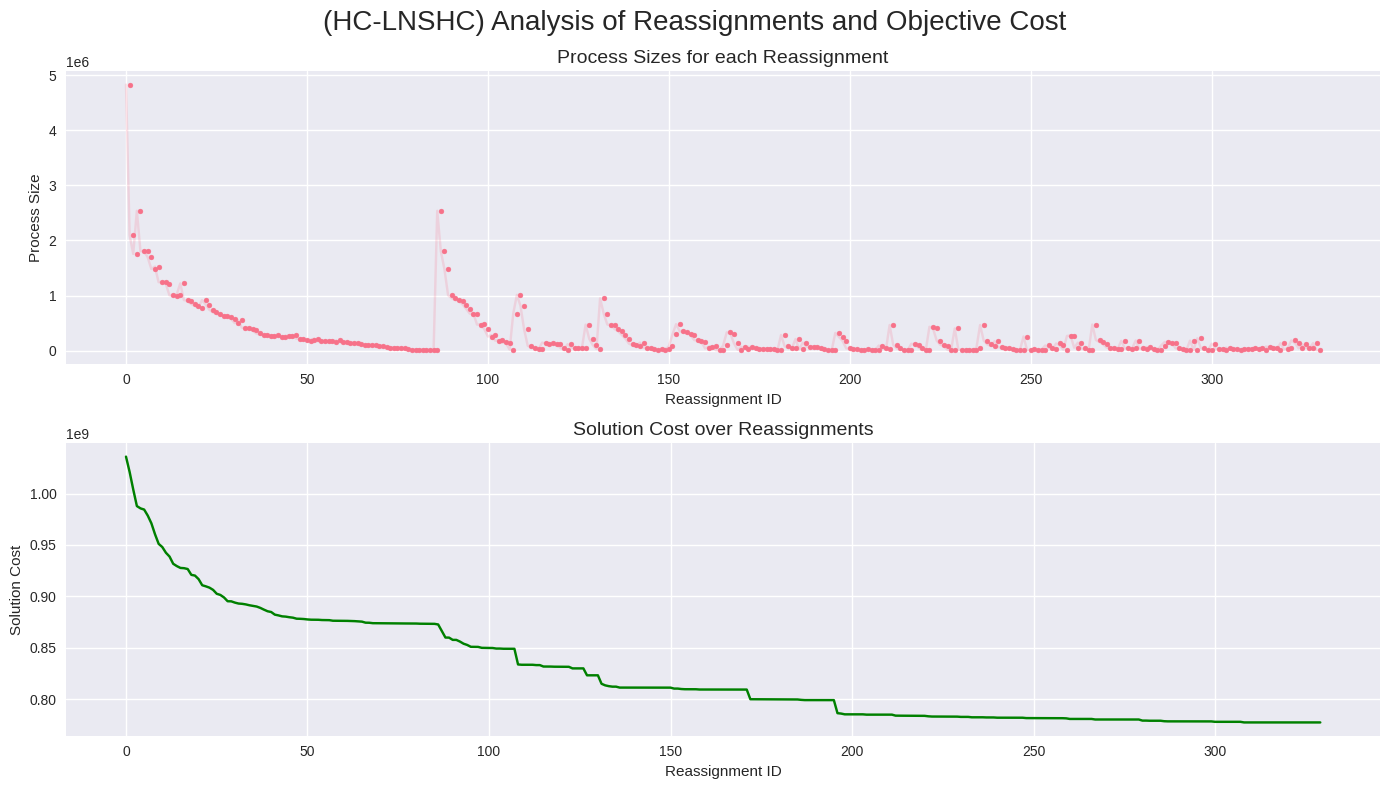

# Single Plots
---

In [29]:
def plot_reassignments(df, title = None, save_file = None):
    plt.figure(figsize=(14, 6))
    plt.scatter(df['MoveNum'], df['ProcessSize'], marker='.')
    plt.plot(df['ProcessSize'], alpha=0.2)
    plt.xlabel('Reassignment ID')
    plt.ylabel('Process Size')
    if title: plt.title(title)
    plt.grid()
    if save_file: plt.savefig(f"/home/pbiel/repos/mrp/analysis/images/{save_file}.png", bbox_inches="tight")
    plt.show()


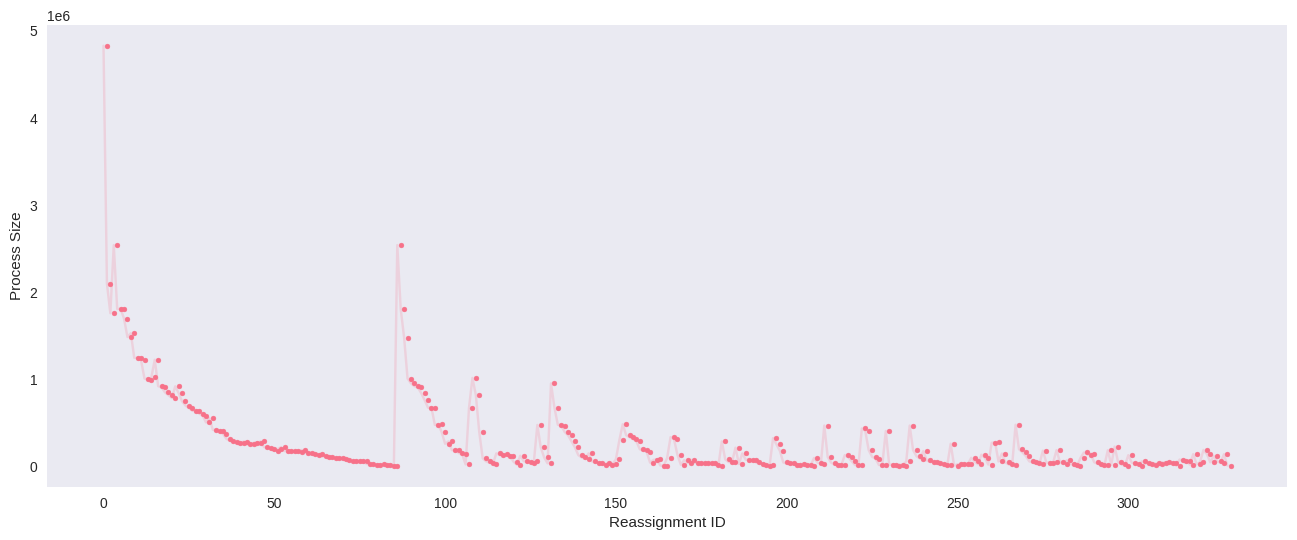

In [33]:
plot_reassignments(hclns_reassignments_df, save_file="hclns_reassignments")


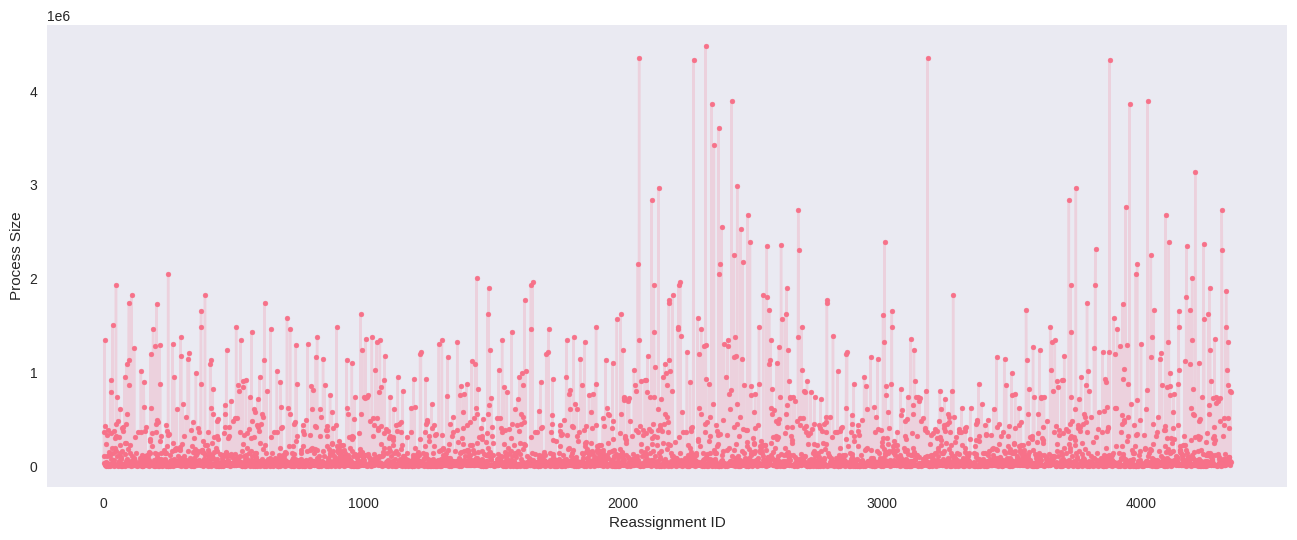

In [34]:
plot_reassignments(vns_reassignments_df, save_file="vns_reassignments")


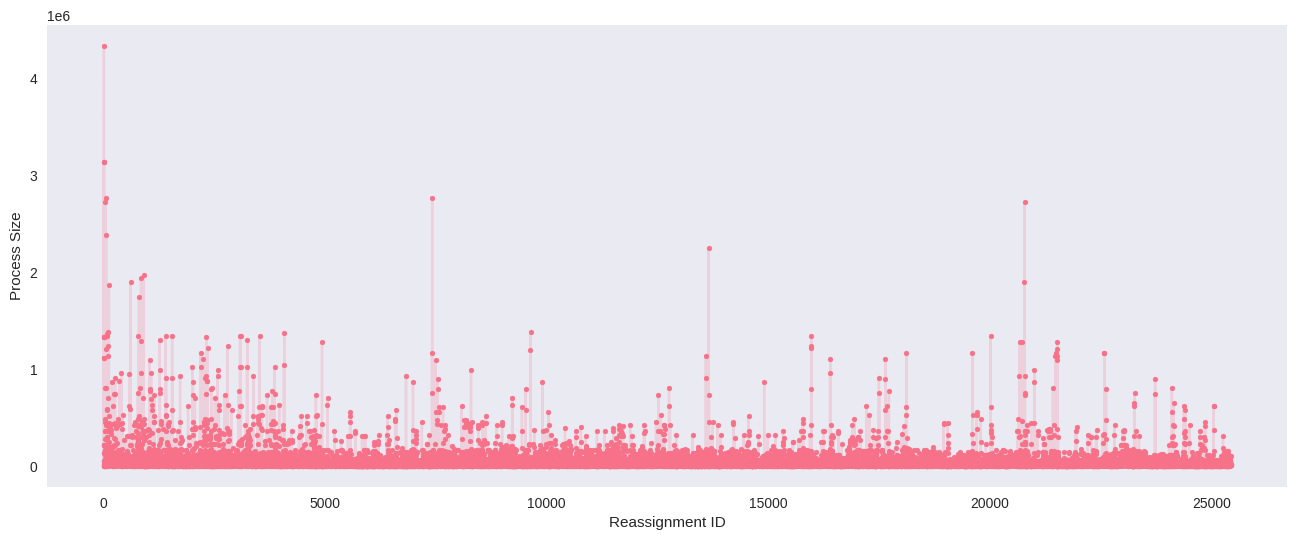

In [69]:
plot_reassignments(cplns_reassignments_df, save_file="cplns_reassignments")


In [56]:
def plot_objective_cost(
        df, 
        title = None, 
        save_file = None, 
        neighborhoods = None
):
    plt.figure(figsize=(14, 6))
    plt.plot(df['SolutionCost'], color="green")
    plt.ylabel('Solution Cost')
    plt.xlabel('Reassignment ID')
    if title: plt.title(title)
    plt.grid(zorder=0)
    for n in neighborhoods:
        plt.axvline(x=n, color='blue', linestyle='--', alpha=0.2, zorder=1)
    
    if save_file: plt.savefig(f"/home/pbiel/repos/mrp/analysis/images/{save_file}.png", bbox_inches="tight")
    plt.show()


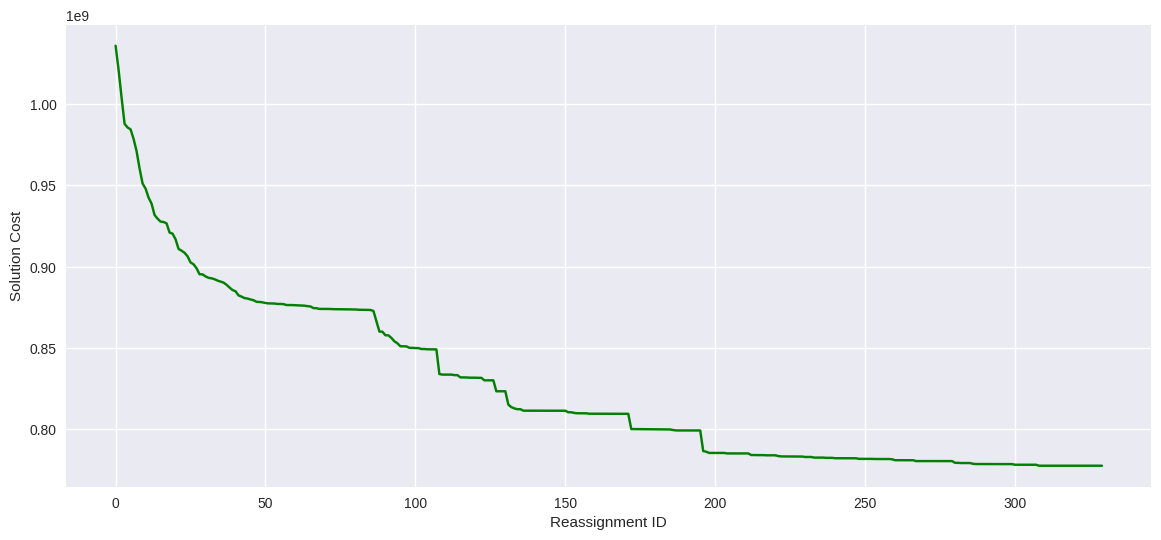

In [46]:
plot_objective_cost(hclns_reassignments_df, save_file="hclns_objective_cost")


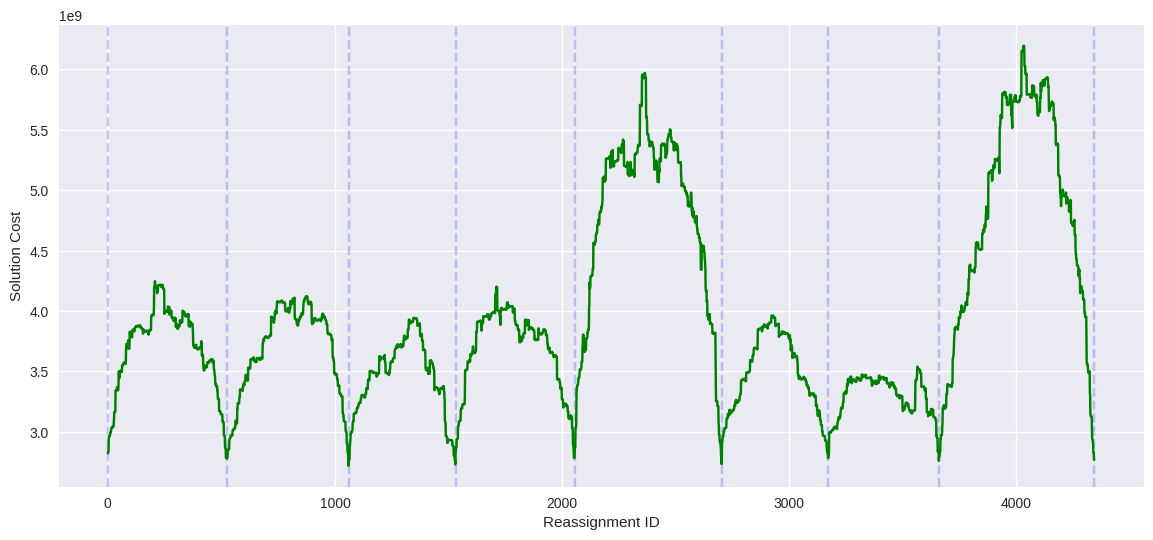

In [57]:
neighborhoods = calculate_points_of_neighbourhood_changes(vns_reassignments_df)
plot_objective_cost(vns_reassignments_df, 
                    save_file="vns_objective_cost",
                    neighborhoods=neighborhoods)


TypeError: 'NoneType' object is not iterable

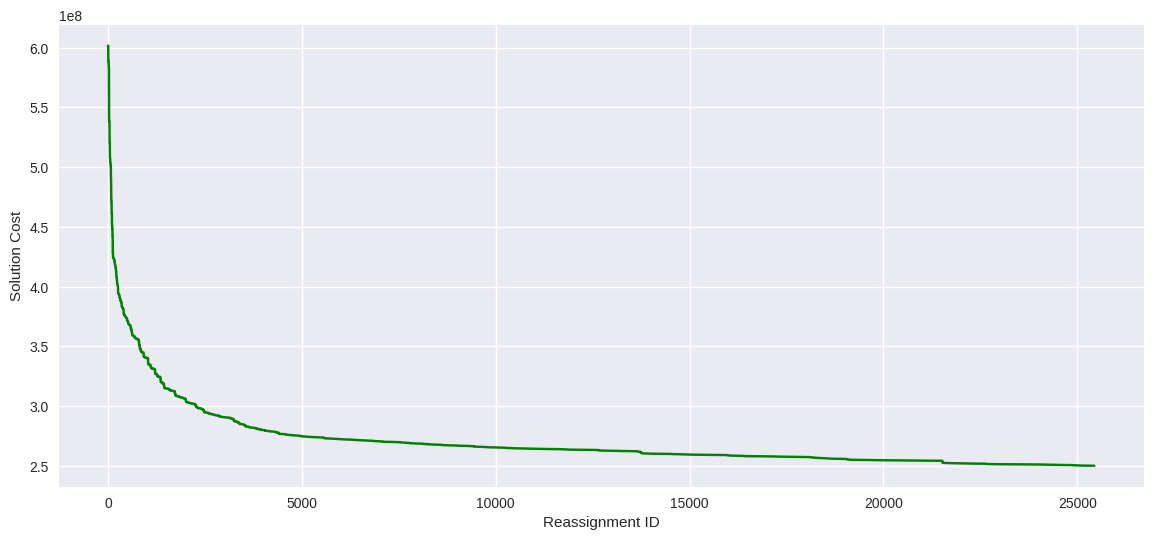

In [70]:
plot_objective_cost(cplns_reassignments_df, save_file="cplns_objective_cost")


# Multiplots of Reassignments and Solution Cost
---

In [ ]:
df = hclns_reassignments_df

n_plots = 2
h_plot  = 4

fig, axs = plt.subplots(n_plots, 1, figsize=(14, n_plots*h_plot))
fig.suptitle("(HC-LNSHC) Analysis of Reassignments and Objective Cost", fontsize=20)

axs = axs.flatten()

idx = 0
axs[idx].scatter(df['MoveNum'], df['ProcessSize'], marker='.')
axs[idx].plot( df['ProcessSize'], alpha=0.2)
axs[idx].set_title("Process Sizes for each Reassignment", fontsize=14)
axs[idx].set_ylabel('Process Size')
axs[idx].set_xlabel('Reassignment ID')

idx = 1
axs[idx].plot(df['SolutionCost'], color="green")
axs[idx].set_title("Solution Cost over Reassignments", fontsize=14)
axs[idx].set_ylabel('Solution Cost')
axs[idx].set_xlabel('Reassignment ID')

for ax in fig.get_axes():
    ax.margins(0.05)
    ax.grid(zorder=0)

plt.tight_layout()


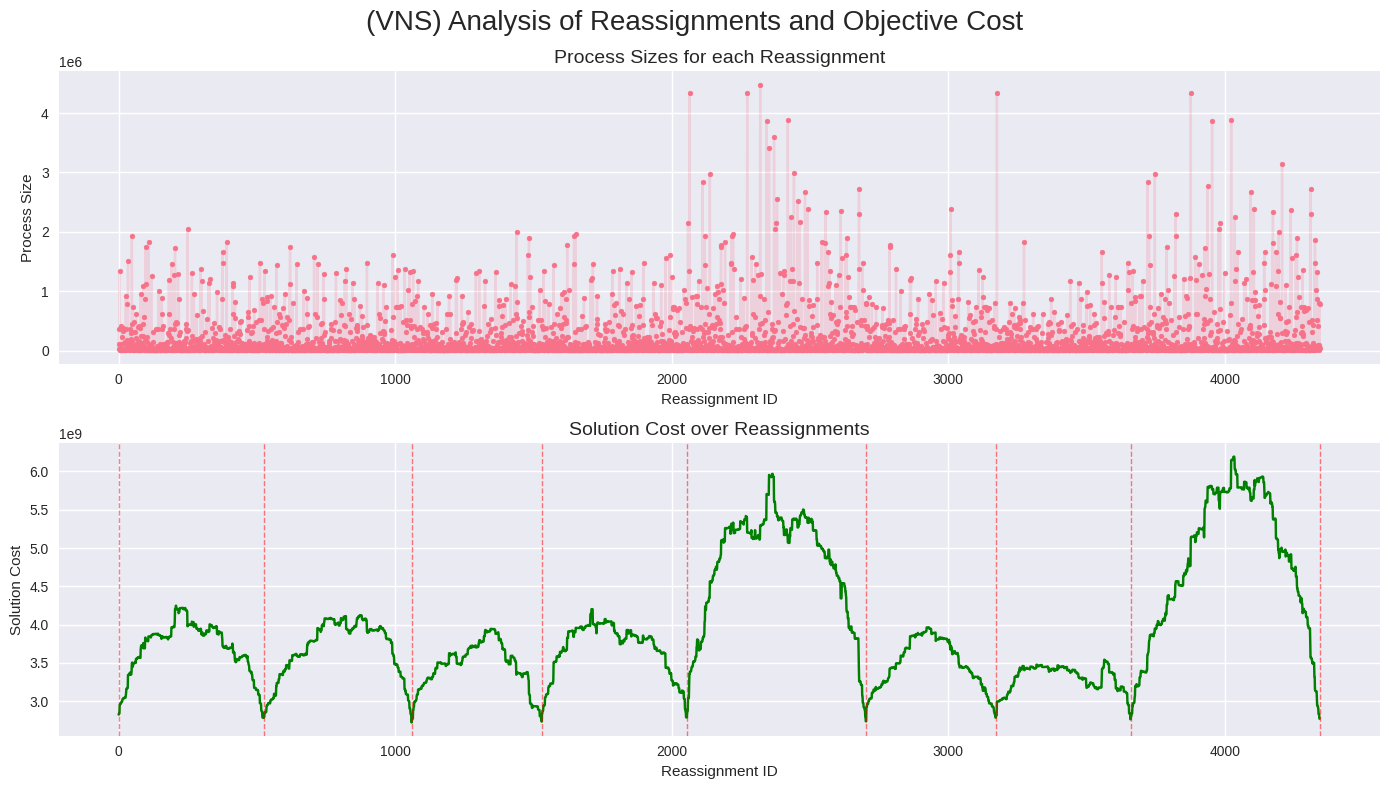

In [96]:
df = vns_reassignments_df

n_plots = 2
h_plot  = 4

fig, axs = plt.subplots(n_plots, 1, figsize=(14, n_plots*h_plot))
fig.suptitle("(VNS) Analysis of Reassignments and Objective Cost", fontsize=20)

axs = axs.flatten()

idx = 0
axs[idx].scatter(df['MoveNum'], df['ProcessSize'], marker='.')
axs[idx].plot( df['ProcessSize'], alpha=0.2)
axs[idx].set_title("Process Sizes for each Reassignment", fontsize=14)
axs[idx].set_ylabel('Process Size')
axs[idx].set_xlabel('Reassignment ID')

idx = 1
axs[idx].plot(df['SolutionCost'], color="green")
axs[idx].set_title("Solution Cost over Reassignments", fontsize=14)
axs[idx].set_ylabel('Solution Cost')
axs[idx].set_xlabel('Reassignment ID')

traversed_neighborhoods = calculate_points_of_neighbourhood_changes(df)
for tn in traversed_neighborhoods:
    axs[idx].axvline(x=tn, color='red', linestyle='--', linewidth=1, alpha=0.5)

for ax in fig.get_axes():
    ax.margins(0.05)
    ax.grid(zorder=0)

plt.tight_layout()


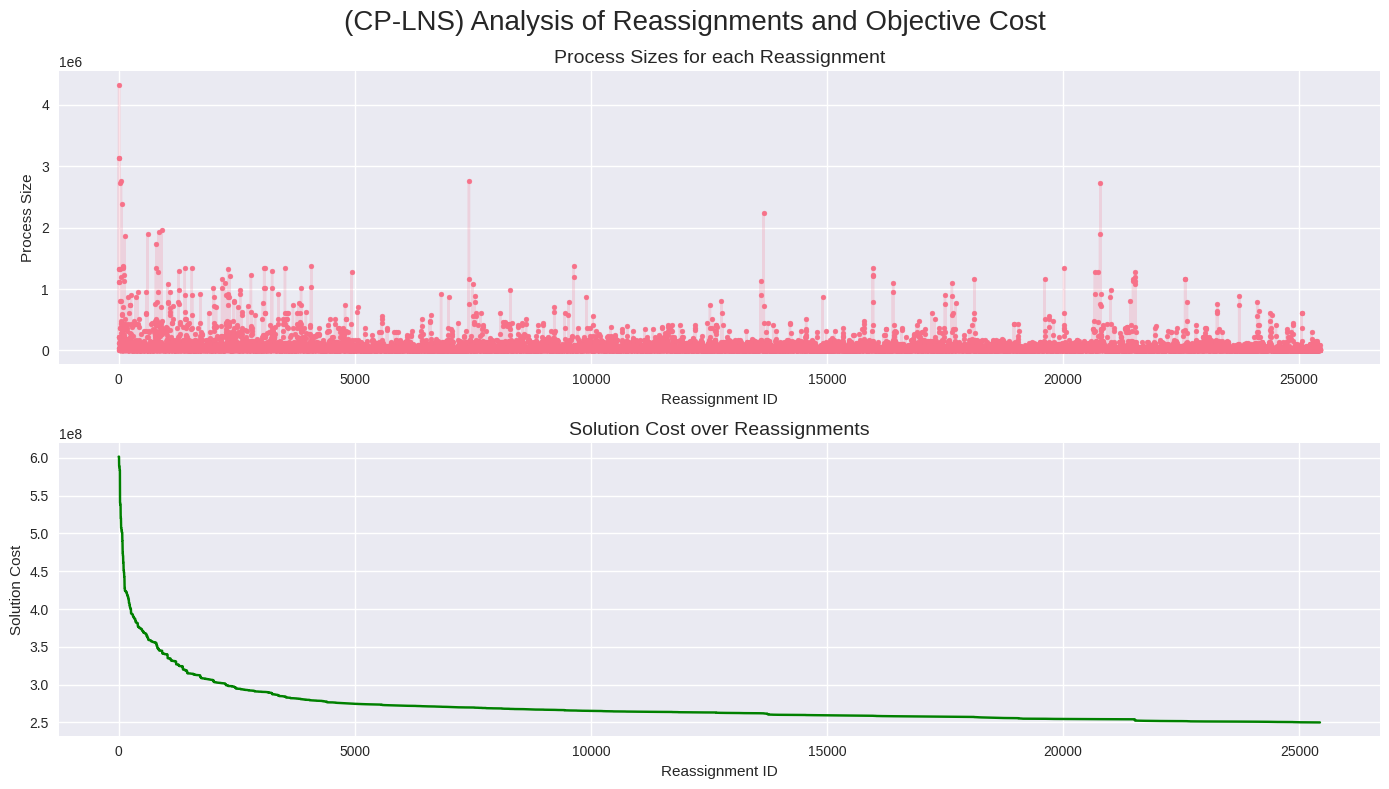

In [76]:
df = cplns_reassignments_df

n_plots = 2
h_plot  = 4

fig, axs = plt.subplots(n_plots, 1, figsize=(14, n_plots*h_plot))
fig.suptitle("(CP-LNS) Analysis of Reassignments and Objective Cost", fontsize=20)

axs = axs.flatten()

idx = 0
axs[idx].scatter(df['MoveNum'], df['ProcessSize'], marker='.')
axs[idx].plot( df['ProcessSize'], alpha=0.2)
axs[idx].set_title("Process Sizes for each Reassignment", fontsize=14)
axs[idx].set_ylabel('Process Size')
axs[idx].set_xlabel('Reassignment ID')

idx = 1
axs[idx].plot(df['SolutionCost'], color="green")
axs[idx].set_title("Solution Cost over Reassignments", fontsize=14)
axs[idx].set_ylabel('Solution Cost')
axs[idx].set_xlabel('Reassignment ID')

for ax in fig.get_axes():
    ax.margins(0.05)
    ax.grid(zorder=0)

plt.tight_layout()
